In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

import config
import data_load as dl
import data_pipeline as dp

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

In [2]:
# =============================================================================
# CELL 2: LOAD METADATA & LABELS
# =============================================================================
meta = dl.load_metadata(config.CFG["data_dir"])
scp_path = os.path.join(config.CFG["data_dir"], "scp_statements.csv")
scp_diag = pd.read_csv(scp_path, index_col=0)

Y, mlb, class_names, meta_labeled = dp.build_label_matrix(
    meta, scp_diag, threshold=config.CFG["label_thresh"]
)

17:01:48 | INFO     | Loading metadata from D:\DEPI\ECG project\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv...
17:01:48 | INFO     | Dropped 0 duplicate records. 21799 records remain.
17:01:48 | INFO     | Masked ages (300 -> NaN): 293 patients aged >89.
17:01:49 | INFO     | Records with >=1 diagnostic label: 21375 (424 dropped).
17:01:49 | INFO     | Label matrix Y shape: (21375, 5) | Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
17:01:49 | INFO     | Class CD    :   4898 (22.9%)
17:01:49 | INFO     | Class HYP   :   2649 (12.4%)
17:01:49 | INFO     | Class MI    :   5469 (25.6%)
17:01:49 | INFO     | Class NORM  :   9514 (44.5%)
17:01:49 | INFO     | Class STTC  :   5108 (23.9%)


C:\Users\imana\AppData\Local\Temp\ipykernel_18868\3053205514.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_names, y=sorted_counts, palette="viridis")


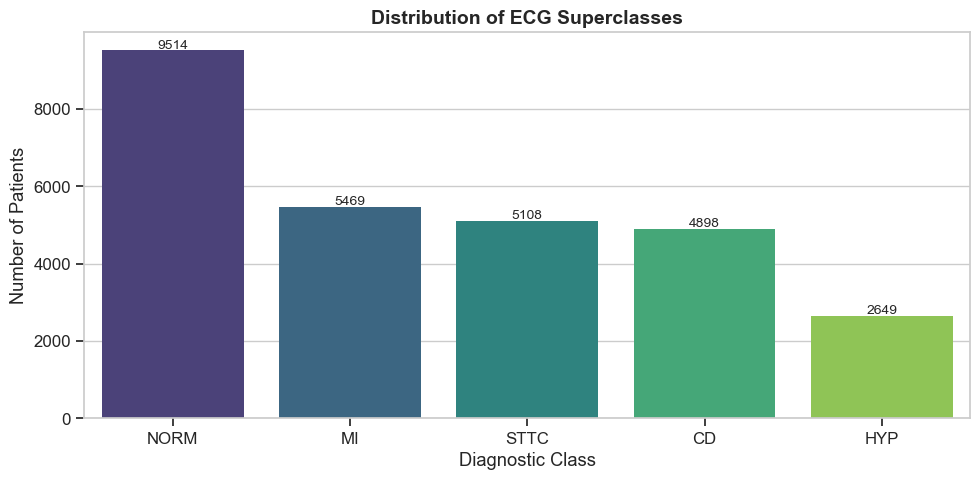

In [3]:
# =============================================================================
# CELL 3: CLASS DISTRIBUTION (IMBALANCE CHECK)
# =============================================================================
plt.figure(figsize=(10, 5))

class_counts = Y.sum(axis=0)

sort_idx = np.argsort(class_counts)[::-1]
sorted_counts = class_counts[sort_idx]
sorted_names = [class_names[i] for i in sort_idx]

sns.barplot(x=sorted_names, y=sorted_counts, palette="viridis")
plt.title("Distribution of ECG Superclasses", fontsize=14, fontweight='bold')
plt.ylabel("Number of Patients")
plt.xlabel("Diagnostic Class")

for i, v in enumerate(sorted_counts):
    plt.text(i, v + 50, str(int(v)), ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

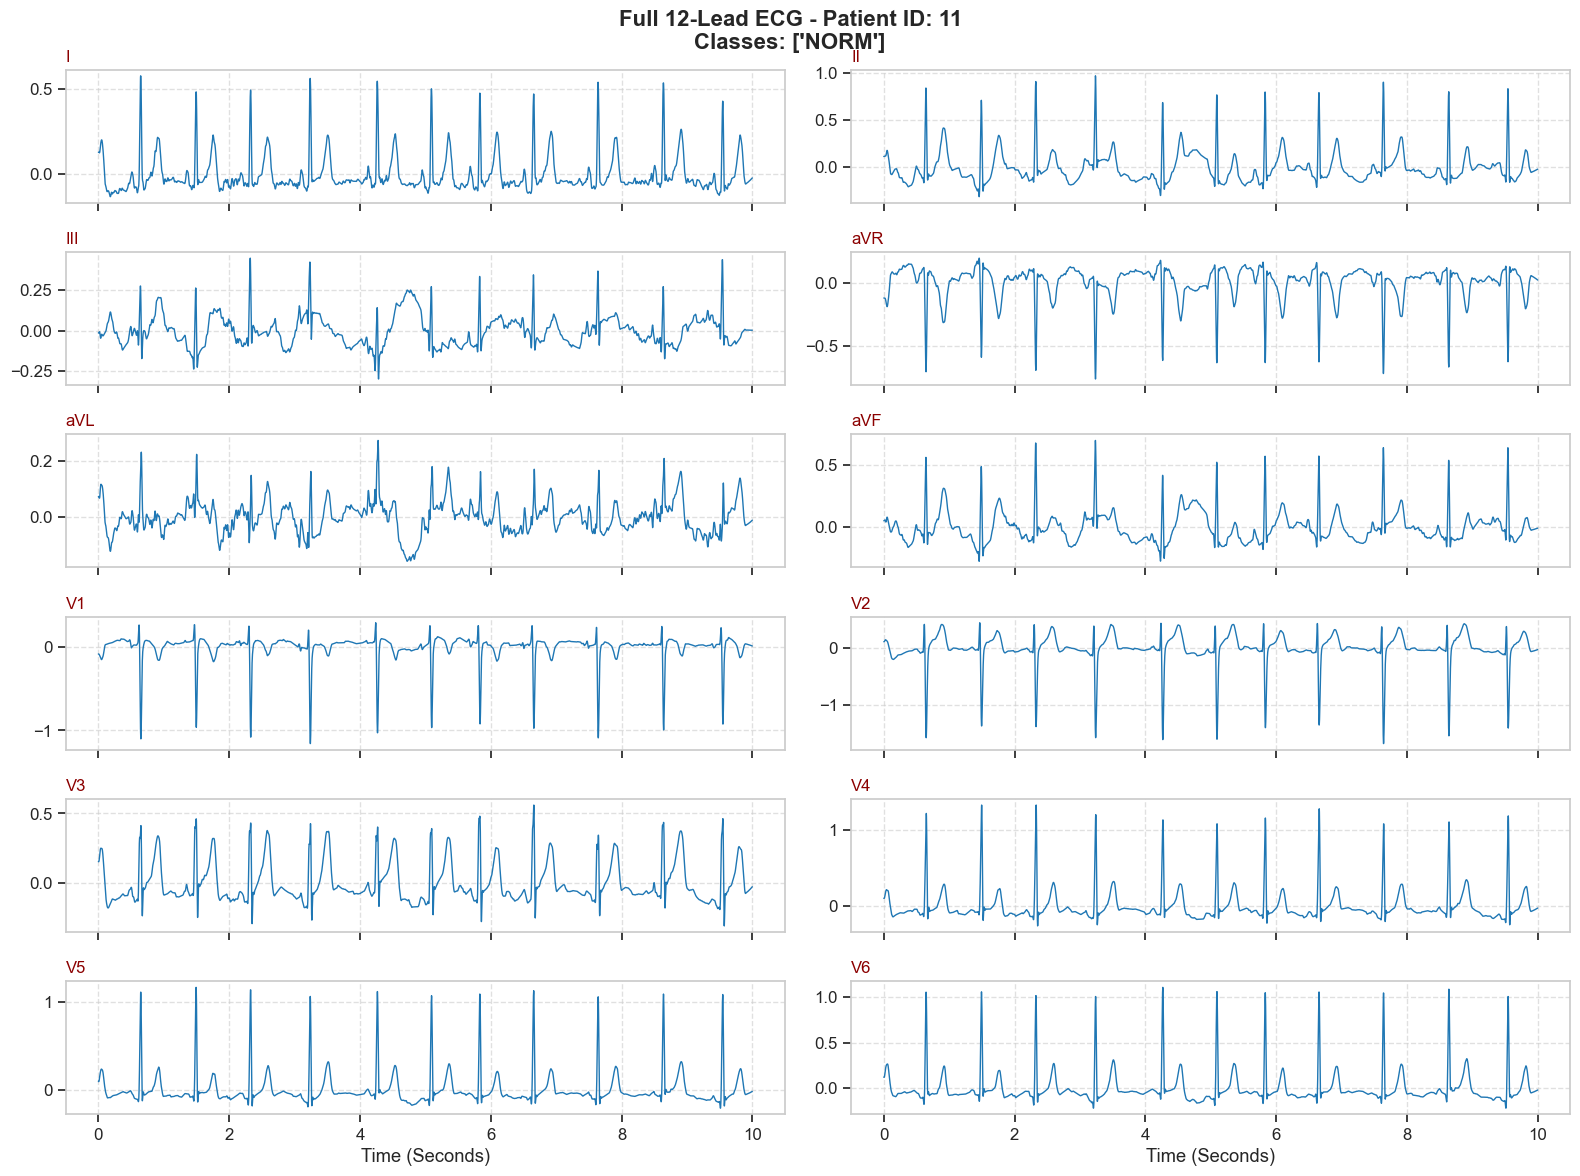

In [4]:
# =============================================================================
# CELL 4: FULL 12-LEAD ECG VISUALIZATION
# =============================================================================
sample_id = meta_labeled.index[10]
sample_path = os.path.join(config.CFG["data_dir"], meta_labeled.loc[sample_id, "filename_hr"])

sig_raw, _ = wfdb.rdsamp(sample_path)
sig_clean = dp.clean_single_signal(sig_raw)
sig_filt = dp.bandpass_filter_single(
    sig_clean, fs=config.CFG["sampling_rate"], 
    low=config.CFG["bandpass_low"], high=config.CFG["bandpass_high"], 
    order=config.CFG["bandpass_ord"]
)

time_axis = np.arange(sig_filt.shape[0]) / config.CFG["sampling_rate"]

fig, axes = plt.subplots(6, 2, figsize=(16, 12), sharex=True)
fig.suptitle(f"Full 12-Lead ECG - Patient ID: {sample_id}\nClasses: {meta_labeled.loc[sample_id, 'diagnostic_superclass']}", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < 12:
        ax.plot(time_axis, sig_filt[:, i], color='#1f77b4', linewidth=1)
        ax.set_title(config.LEAD_NAMES[i], loc='left', fontsize=12, color='darkred')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i >= 10: 
            ax.set_xlabel("Time (Seconds)")

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()